<a href="https://colab.research.google.com/github/tomonari-masada/course2026-intro2ml/blob/main/loss_function_of_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 単変量でバイアスありのロジスティック回帰の損失関数の3次元プロット

weight: 2.668	bias: -13.182
bias / weight: -4.94


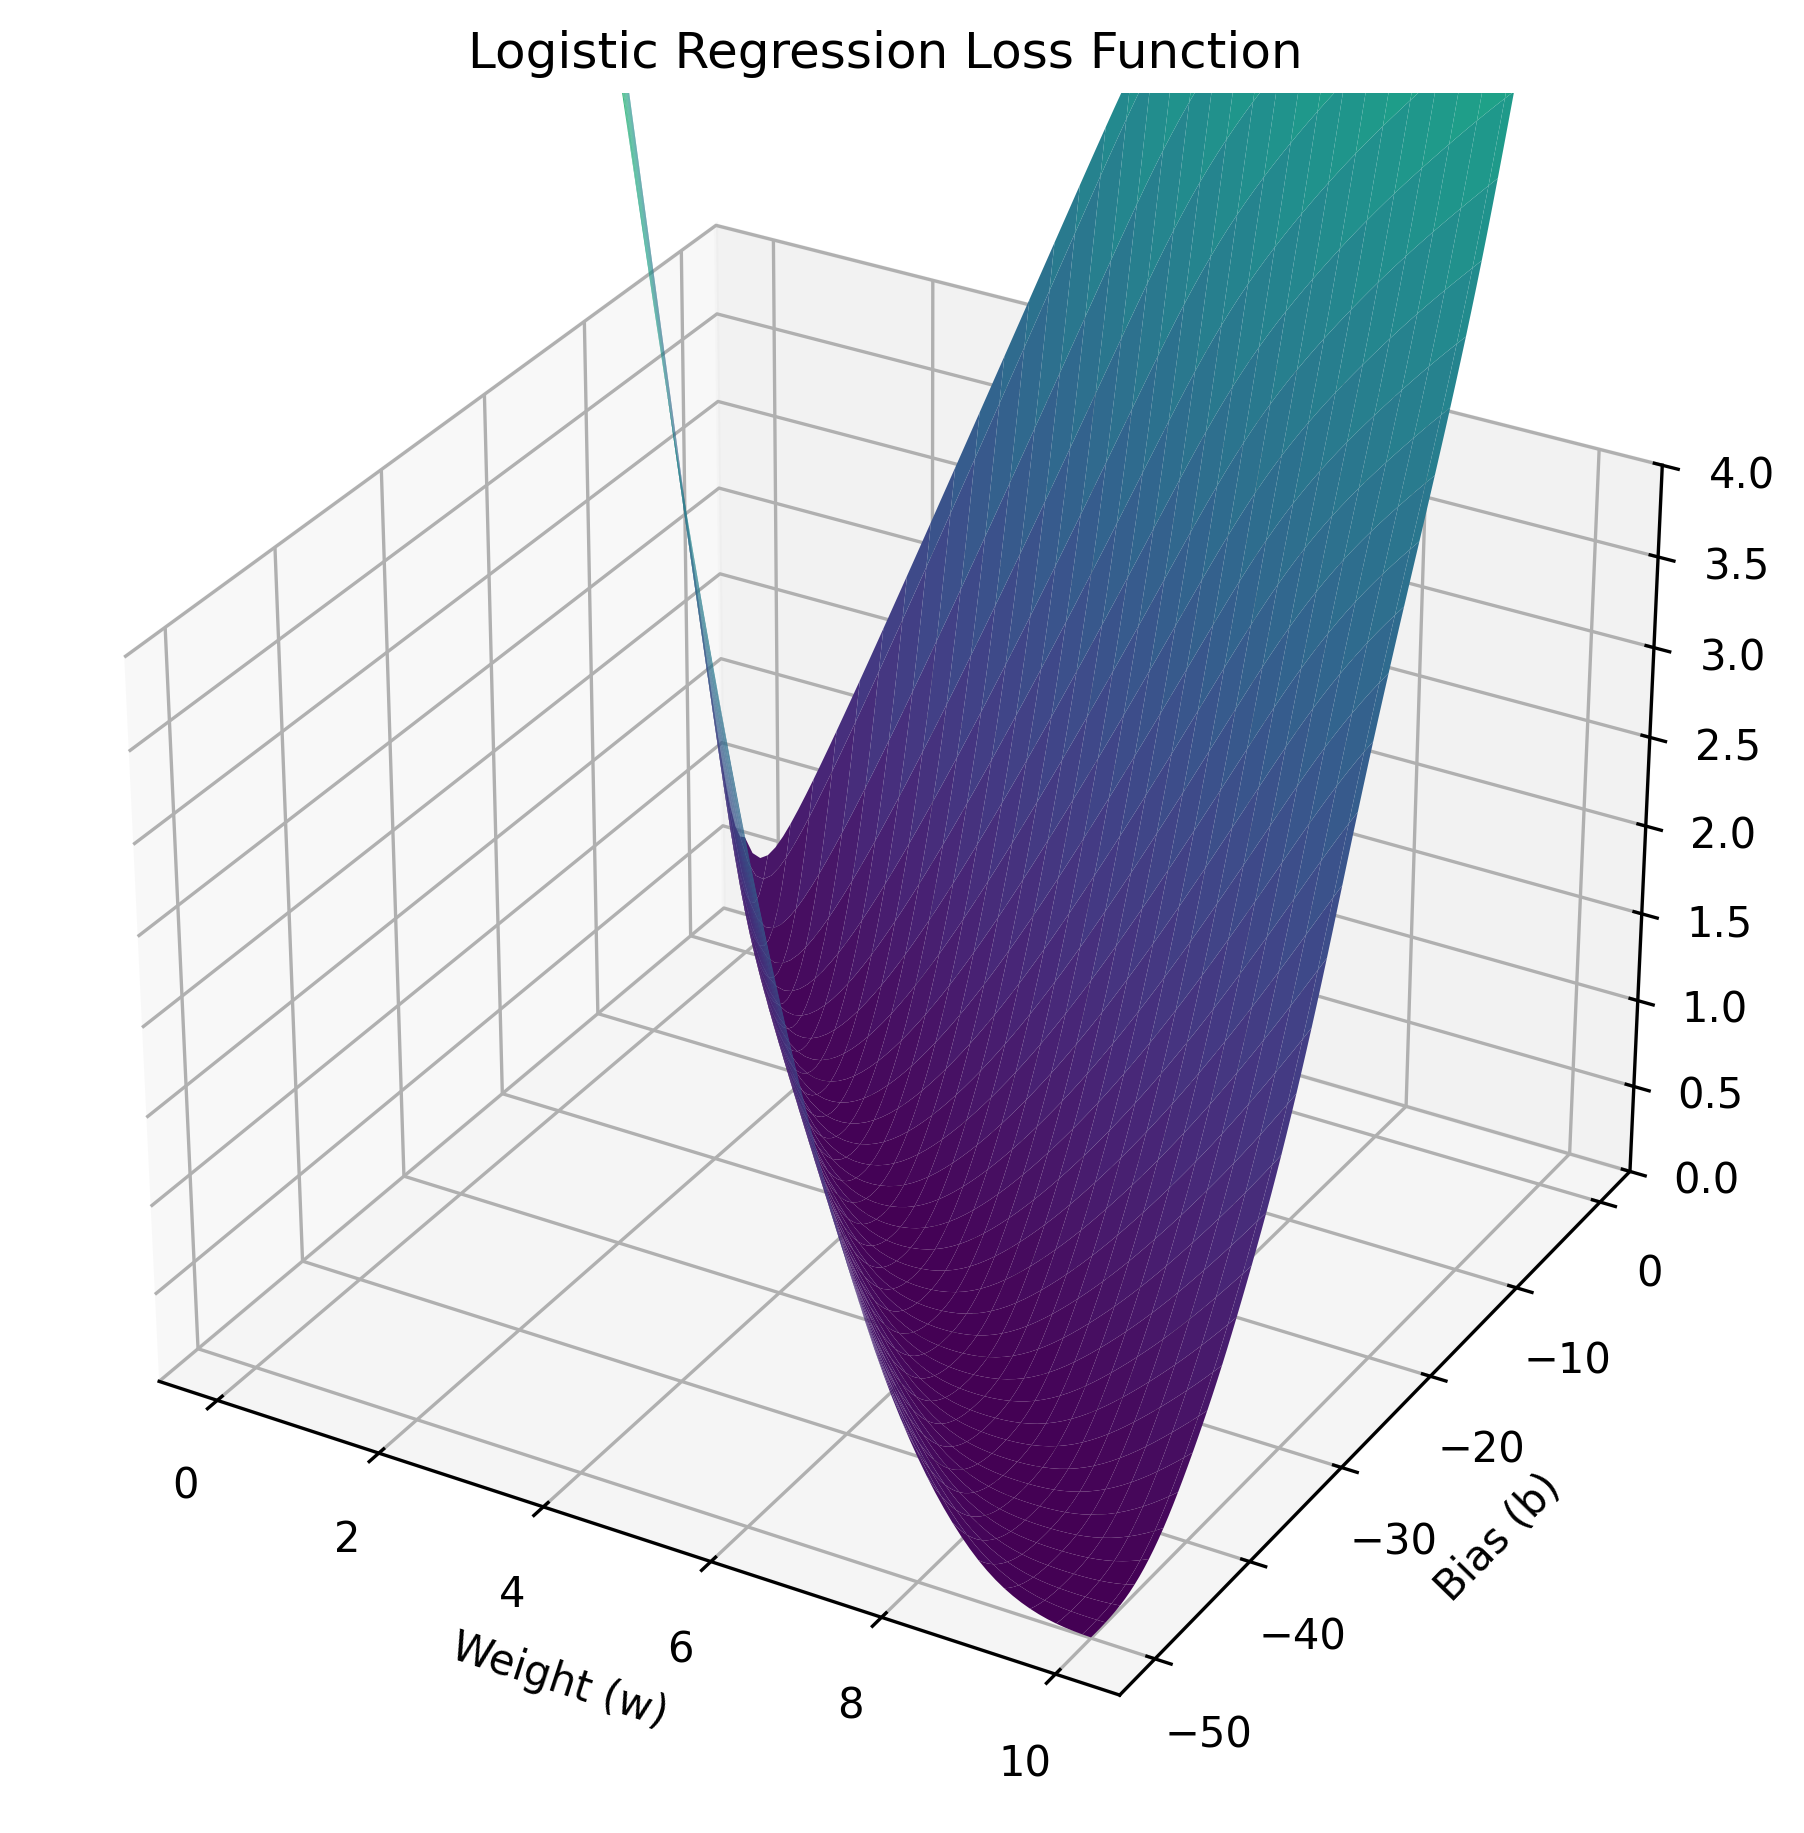

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LogisticRegression

#高解像度のプロットの設定
plt.rcParams['figure.dpi'] = 300

# シグモイド関数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ロジスティック回帰の損失関数
def logistic_loss(w, b, X, y):
    m = len(y)
    z = w * X + b
    h = sigmoid(z)
    # ロジスティック回帰の損失関数
    loss = - (1/m) * np.sum(y * np.log(h + 1e-10) + (1 - y) * np.log(1 - h + 1e-10))
    return loss
# データの生成
np.random.seed(0)
X = np.random.rand(100) * 10  # 0から10の乱数
y = (X > 5).astype(int)  # 5より大きい場合は1、それ以外は0
# このようにyを決めた場合は、biasがweightの-5倍であれば100%正確に分類できる。

clf = LogisticRegression(solver='lbfgs')
clf.fit(X.reshape(-1, 1), y)
print(f"weight: {clf.coef_[0][0]:.3f}", end="\t")
print(f"bias: {clf.intercept_[0]:.3f}")
print(f"bias / weight: {clf.intercept_[0]/clf.coef_[0][0]:.2f}")

# wとbの範囲を設定
w_range = np.linspace(0, 10, 101)
b_range = np.linspace(-50, 0, 101)
W, B = np.meshgrid(w_range, b_range)
# 損失関数の値を計算
Z = np.array([[logistic_loss(w, b, X, y) for w in w_range] for b in b_range])
# 3Dプロット
fig = plt.figure(figsize=(6, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, Z, cmap='viridis')
ax.set_xlabel('Weight (w)')
ax.set_ylabel('Bias (b)')
ax.set_zlim(0, 4)
ax.set_title('Logistic Regression Loss Function')
plt.tight_layout()
plt.show();